In [3]:
#Dendogram
#1. Load the dataset into a pandas DataFrame. What does the data represent?
import pandas as pd
data = {
    'CustomerID':[1,2,3,4,5,6,7,8,9,10],
    'Annual Income':[15,16,17,18,19,20,21,22,23,24],
    'Spending Score':[39,81,6,77,40,76,6,94,3,72]
}
df = pd.DataFrame(data)

print("This dataset represents customers with their annual income and spending score.")

This dataset represents customers with their annual income and spending score.


In [5]:
#2. Select the features Annual Income and Spending Score for clustering. Why do we choose these?
X = df[['Annual Income', 'Spending Score']]
print(X)

print("We choose these features because they show how much a customer earns and how much they spend, which helps group similar customers.")

   Annual Income  Spending Score
0             15              39
1             16              81
2             17               6
3             18              77
4             19              40
5             20              76
6             21               6
7             22              94
8             23               3
9             24              72
We choose these features because they show how much a customer earns and how much they spend, which helps group similar customers.


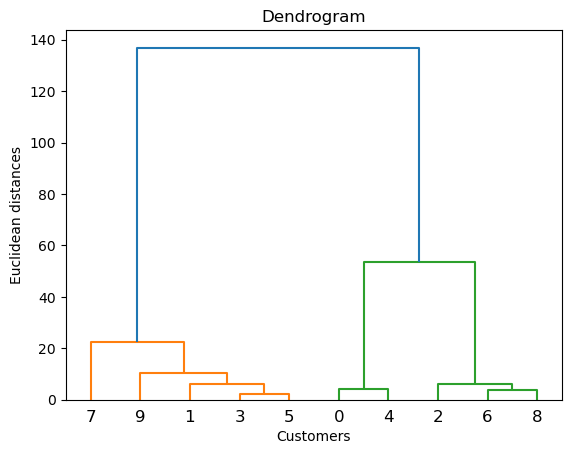

The dendrogram shows how customers are grouped together at different distance levels.


In [7]:
#3. Generate a dendrogram using scipy. What does it represent?
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Create the linkage matrix
linked = sch.linkage(X, method='ward')

# Plotting the dendrogram
sch.dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()
print("The dendrogram shows how customers are grouped together at different distance levels.")

In [8]:
#4. How do you decide the optimal number of clusters from the dendrogram?
print("""Look for the longest vertical distance without horizontal lines crossing it. 
That gap shows where to cut and decide the number of clusters.""")


Look for the longest vertical distance without horizontal lines crossing it. 
That gap shows where to cut and decide the number of clusters.


In [11]:
#5. Apply Agglomerative Clustering with the chosen number of clusters. What are the final cluster assignments?
from sklearn.cluster import AgglomerativeClustering

# Assume we choose 3 clusters based on the dendrogram
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
#linkage= method to decide how to measure the distance between the clusters
y = cluster.fit_predict(X)
print("Cluster assignments:", y)
print("This code assigns each customer to one of the clusters.")

Cluster assignments: [2 0 1 0 2 0 1 0 1 0]
This code assigns each customer to one of the clusters.


In [16]:
#6. Interpret the clusters. What business insights can be derived?
df['Cluster'] = y
print(df)

for cluster in sorted(df['Cluster'].unique()):
    group=df[df['Cluster']==cluster]
    print(f"\nCluster {cluster} Summary")
    print(group[['Annual Income', 'Spending Score']].describe())

print("\nInsights:")
print("Customers in the same cluster have similar income and spending habits.")
print("This helps in targeted marketing and improving customer experience.")

print("interpretation of cluster 0 = as Annual income increases,spending increases")
print("interpretation of cluster 1 = as Annual income increases,spending doesn't increase..should give more offers so that they can buy more")
print("interpretation of cluster 2 = as Moderately spent")

   CustomerID  Annual Income  Spending Score  Cluster
0           1             15              39        2
1           2             16              81        0
2           3             17               6        1
3           4             18              77        0
4           5             19              40        2
5           6             20              76        0
6           7             21               6        1
7           8             22              94        0
8           9             23               3        1
9          10             24              72        0

Cluster 0 Summary
       Annual Income  Spending Score
count       5.000000        5.000000
mean       20.000000       80.000000
std         3.162278        8.455767
min        16.000000       72.000000
25%        18.000000       76.000000
50%        20.000000       77.000000
75%        22.000000       81.000000
max        24.000000       94.000000

Cluster 1 Summary
       Annual Income  Spending Scor